## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [3]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

## Import Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
visa = pd.read_csv('/content/drive/MyDrive/utaiml/input/EasyVisa.csv')

In [6]:
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [7]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [8]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
data.shape

(25480, 12)

#### Check the data types of the columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
null_columns = data.isnull().any().sum()
print("Number of columns with nulls:", null_columns)

Number of columns with nulls: 0


In [ ]:
print(data.isnull().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [ ]:
data.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
data.describe(include="all")

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480.000000,25480.000000,25480,25480.000000,25480,25480,25480
unique,25480,6,4,2,2,NaN,NaN,5,NaN,4,2,2
top,EZYV25480,Asia,Bachelor's,Y,N,NaN,NaN,Northeast,NaN,Year,Y,Certified
freq,1,16861,10234,14802,22525,NaN,NaN,7195,NaN,22962,22773,17018
mean,NaN,NaN,NaN,NaN,NaN,5667.043210,1979.409929,NaN,74455.814592,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22877.928848,42.366929,NaN,52815.942327,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,-26.000000,1800.000000,NaN,2.136700,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1022.000000,1976.000000,NaN,34015.480000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2109.000000,1997.000000,NaN,70308.210000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3504.000000,2005.000000,NaN,107735.512500,NaN,NaN,NaN


#### Fixing the negative values in number of employees columns

In [ ]:
data.loc[data['no_of_employees'] < 0].shape

(33, 12)

In [ ]:
data["no_of_employees"] = abs(data["no_of_employees"])

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [ ]:
# checking the number of unique values
data["case_id"].nunique()

25480

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

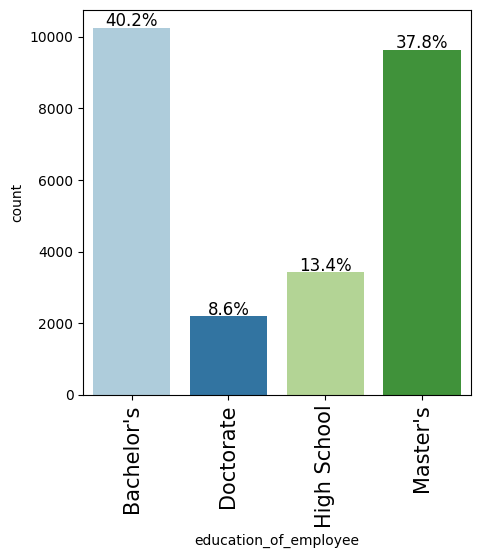

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)

#### Observations on region of employment

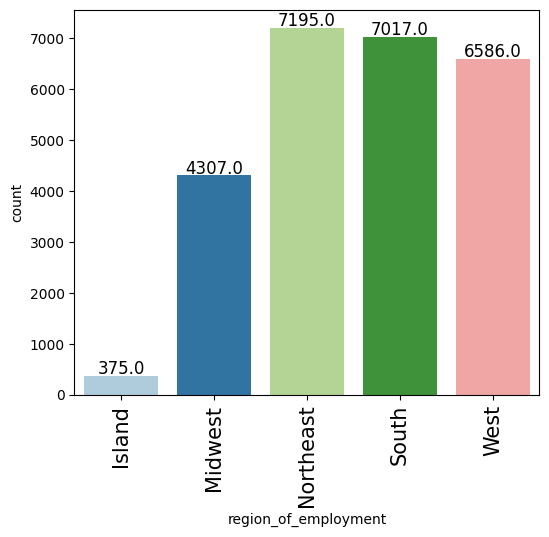

In [ ]:
labeled_barplot(data,'region_of_employment')

#### Observations on job experience

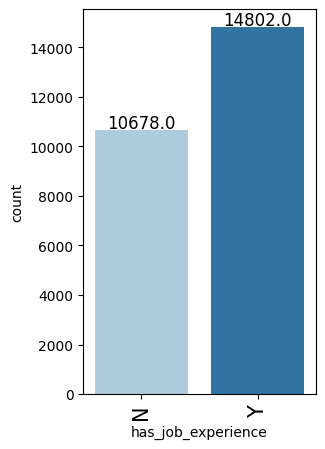

In [ ]:
labeled_barplot(data,'has_job_experience')

#### Observations on case status

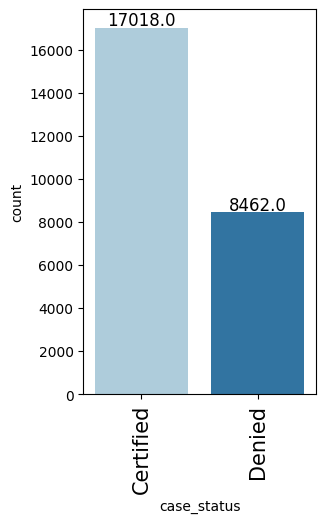

In [ ]:
labeled_barplot(data,'case_status')

### Bivariate Analysis

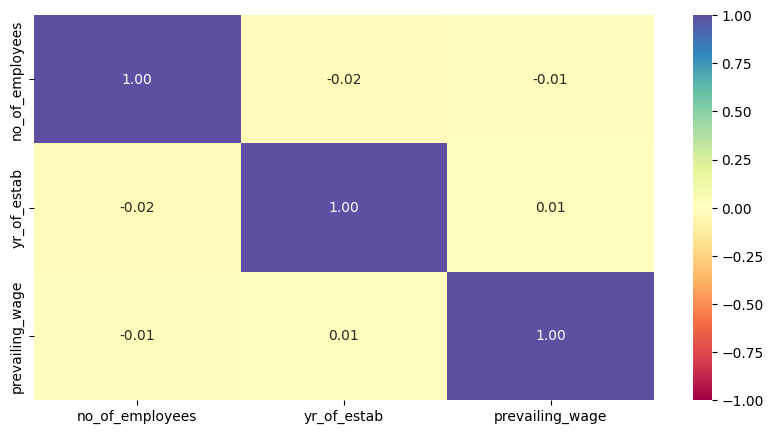

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()


**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Those with higher education may want to travel abroad for a well-paid job. Let's find out if education has any impact on visa certification

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


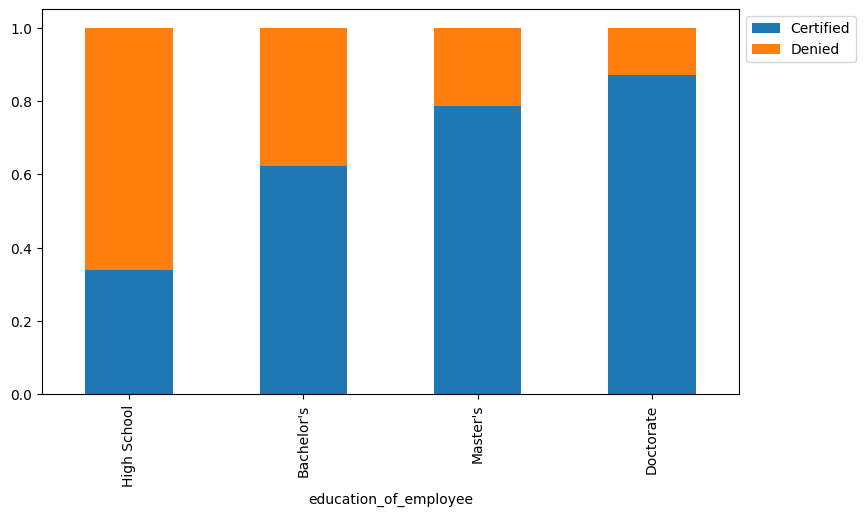

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

#### Lets' similarly check for the continents and find out how the visa status vary across different continents.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


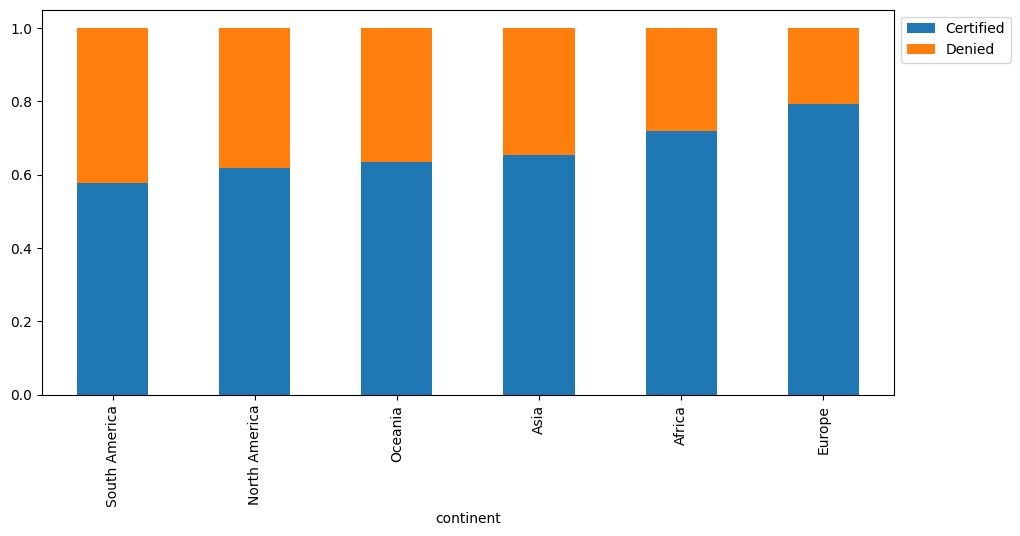

In [ ]:
stacked_barplot(data, "continent", "case_status")

#### Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Let's see if having work experience has any influence over visa certification

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


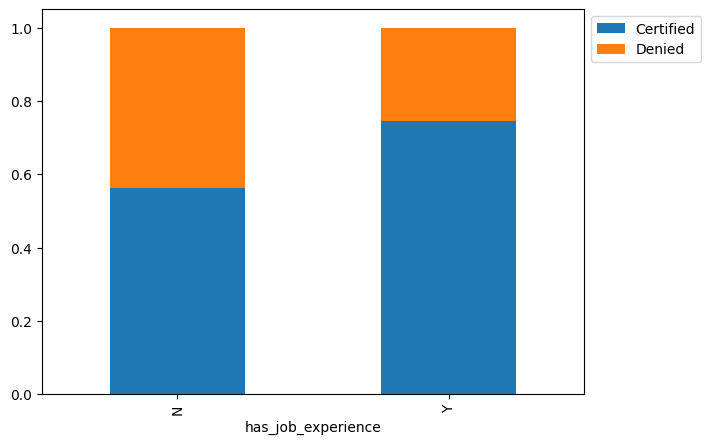

In [ ]:
stacked_barplot(data, "has_job_experience", "case_status")

#### Checking if the prevailing wage is similar across all the regions of the US

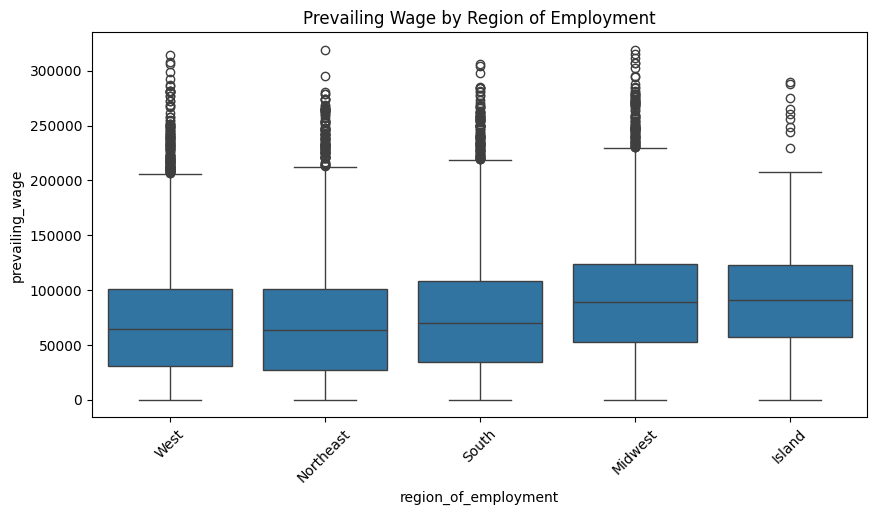

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='region_of_employment', y='prevailing_wage', data=data)
plt.xticks(rotation=45)  # rotate x-axis labels for readability
plt.title('Prevailing Wage by Region of Employment')
plt.show()

#### The US government has established a prevailing wage to protect local talent and foreign workers. Let's analyze the data and see if the visa status changes with the prevailing wage

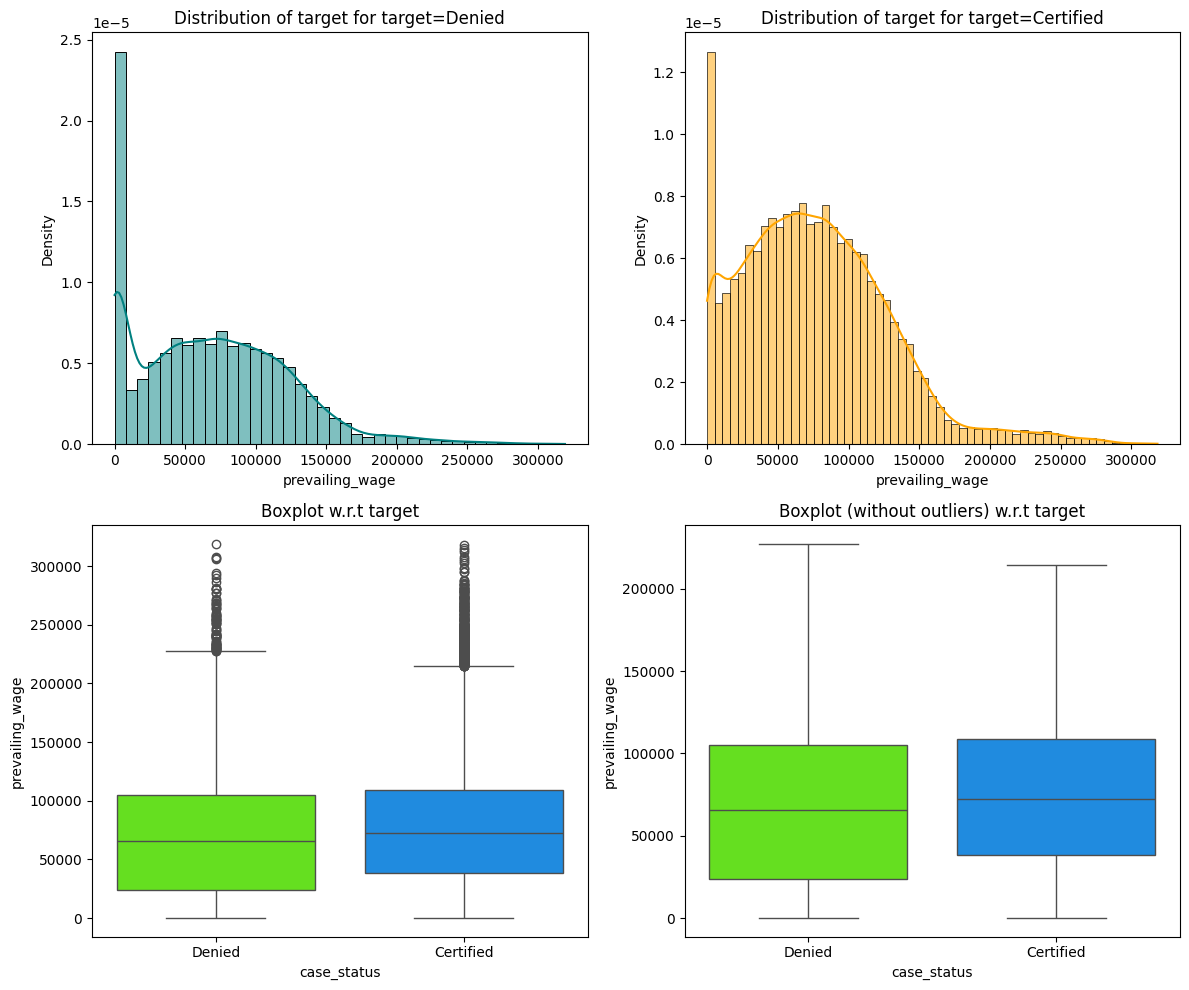

In [ ]:
distribution_plot_wrt_target(data=data, predictor='prevailing_wage', target='case_status')


#### The prevailing wage has different units (Hourly, Weekly, etc). Let's find out if it has any impact on visa applications getting certified.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


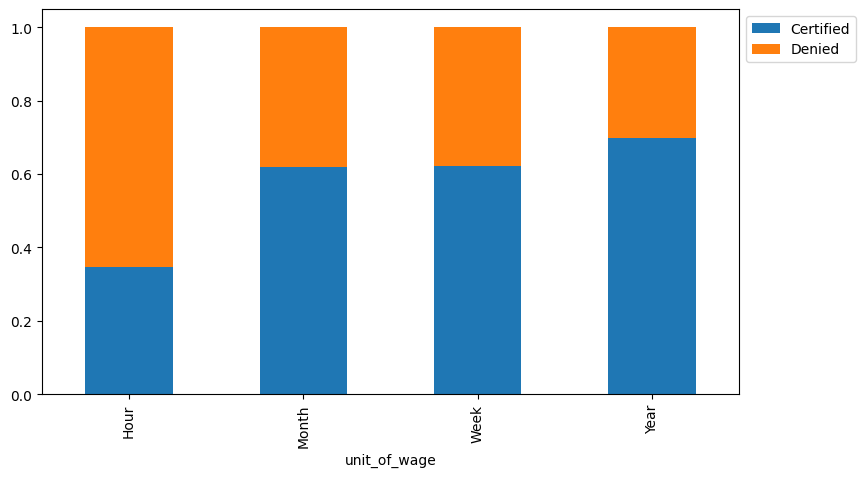

In [ ]:
stacked_barplot(data, 'unit_of_wage', 'case_status')


###  Key Observations & Insights from EDA

#### 1. Univariate Insights
- **Education of Employee**: Majority of applicants hold a **Bachelor’s** or **Master’s** degree. Very few have only High School or Doctorate qualifications.  
- **Continent**: Most applicants come from **Asia**, followed by **Europe** and **North America**.  
- **Job Experience**: About **58%** of applicants have prior work experience.  
- **Job Training Requirement**: Nearly **88%** of applicants do **not** require job training.  
- **Unit of Wage**: Predominantly offered on a **Yearly** basis (~90%).  
- **Full-time Position**: Most positions are **full-time** (~89%).  
- **Case Status Distribution**: Overall, **Certified visas (~67%)** are nearly twice as frequent as **Denied visas (~33%)**.  


#### 2. Relationships with Visa Status (Bivariate Insights)
- **Education vs Case Status**: Approval rate increases with higher education.  
  - **Doctorate** and **Masters** applicants have the highest approval rates.  
  - **High School** applicants have the lowest (~34%).  
- **Continent vs Case Status**:  
  - **Europe** has the highest success (~80%).  
  - **South America** has the lowest (~58%).  
- **Job Experience vs Case Status**:  
  - With experience → ~75% certified.  
  - Without experience → ~56% certified.  
- **Prevailing Wage vs Case Status**:  
  - Certified applicants generally offered **higher wages**.  
  - Denied cases are clustered in **lower wage ranges**.  
- **Unit of Wage vs Case Status**:  
  - **Yearly/Weekly** wages → higher approval.  
  - **Hourly** wages → highest rejection rates.  
- **Region of Employment vs Wages**:  
  - Wage levels differ by region: **Midwest/Island** regions show higher medians, while **West/Northeast** are lower.  
  - Higher wages across regions align with **higher approval rates**.  


**Conclusion**: Education, prior job experience, prevailing wage (and its unit), and continent strongly influence visa certification outcomes. These drivers will be critical features in model building.


## Data Pre-processing

In [ ]:
# Check missing values
print("Missing values per column:")
print(data.isnull().sum())

# Check duplicates
print("Number of duplicate rows:", data.duplicated().sum())


Missing values per column:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64
Number of duplicate rows: 0


### Outlier Check

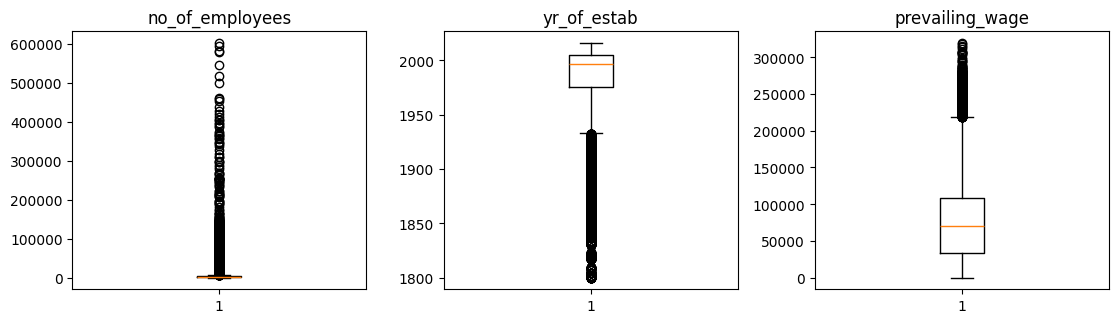

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()


### Outlier Detection and Treatment

- **no_of_employees**:  
  A few extreme outliers are visible. Since company sizes can legitimately vary from very small startups to very large enterprises, we do not remove these values. However, earlier negative values were corrected using the absolute function.

- **yr_of_estab**:  
  Most companies were established between the late 1800s and early 2000s. Although some very old establishment years appear as outliers, they are realistic and were retained.

- **prevailing_wage**:  
  The distribution shows a heavy right skew with extreme high values. These outliers likely represent specialized or high-paying roles. Instead of removing them, we applied a log transformation to normalize the distribution.

- **log_prevailing_wage**:  
  After log transformation, the distribution is more symmetric, reducing the influence of extreme values on the model.

**Conclusion**:  
No rows were dropped. Outliers were handled by transformation (log for wages) and correction (absolute values for number of employees).


In [ ]:
# Wage normalization to yearly basis
unit_map = {
    'Hour': 2080,   # 40 hours * 52 weeks
    'Week': 52,
    'Month': 12,
    'Year': 1
}
data['annual_wage'] = data['prevailing_wage'] * data['unit_of_wage'].map(unit_map)

# Company age from establishment year (reference year 2016)
data['company_age'] = (2016 - data['yr_of_estab']).clip(lower=0)

# Drop identifier
data = data.drop(columns=['case_id'])


### Feature Engineering Rationale

1. **Annual Wage**
- The `prevailing_wage` column was originally reported in different units (Hourly, Weekly, Monthly, Yearly).  
- To make wages comparable, all values were converted to a yearly basis using standard multipliers.  
- This ensures consistency and avoids misleading comparisons across applications.

2. **Company Age**
- The `yr_of_estab` column was converted into `company_age = 2016 - yr_of_estab`.  
- Company age is easier to interpret than the raw establishment year.  
- Older companies are generally more stable and credible, which may influence visa approvals.

3. **Log Transformation of Wages**
- The `prevailing_wage` distribution was highly skewed with extreme outliers.  
- A log transformation (`log_prevailing_wage`) was applied to reduce skewness.  
- This transformation compresses large wage values, en


### Data Preparation for modeling

In [ ]:
# Encode target
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# Drop target from features
X = data.drop(columns=["case_status"])
y = data["case_status"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split: Train (70%) and Validation+Test (30%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Split Validation+Test (30%) into Validation (90%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.1, random_state=1, stratify=y_val
)

print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of Test set : ", X_test.shape)

print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))

print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))

print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))


Shape of Training set :  (17836, 23)
Shape of Validation set :  (6879, 23)
Shape of Test set :  (765, 23)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


### Data Preparation for Modeling

- The target variable `case_status` was encoded as Certified = 1 and Denied = 0.  
- The `case_status` column was dropped from the feature matrix `X`.  
- Categorical features were encoded using one-hot encoding, resulting in 24 predictor variables.  
- The dataset was split into three parts:  
  - Training set: 70% (17,836 rows)  
  - Validation set: 27% (6,879 rows)  
  - Test set: 3% (765 rows)  
- Stratified sampling was used to preserve class balance.  
- The class distribution across all splits is consistent:  
  - Certified visas ≈ 67%  
  - Denied visas ≈ 33%

**Conclusion**: The dataset is now prepared for modeling with balanced splits and properly encoded features.


## Model Building

### Model Evaluation Criterion

### Model Evaluation Criterion

- The dataset is slightly imbalanced (Certified ~67%, Denied ~33%).  
- Using **Accuracy alone is not sufficient**, as a trivial model predicting all cases as Certified would already achieve 67% accuracy.  
- **Recall** is important to correctly identify Denied cases, so that weak applications are not mistakenly certified.  
- **Precision** is important to ensure that the cases recommended for certification are truly strong, minimizing wasted effort.  
- **F1-score** balances Precision and Recall, making it a robust metric when both false positives and false negatives are costly.  

**Conclusion**:  
We will evaluate models using **Accuracy and F1-score** as primary metrics, with Recall and Precision reported for additional insights.


In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
scorer = metrics.make_scorer(metrics.f1_score)

#### Defining scorer to be used for cross-validation and hyperparameter tuning

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with original data


Cross-Validation performance on training dataset:

Bagging: 0.7776449953715873
Random forest: 0.8034458688700308
GBM: 0.8246581154917205
Adaboost: 0.8203811572843718
Xgboost: 0.8086006600714775
dtree: 0.7443300736934952

Validation Performance:

Bagging: 0.6854193923535398
Random forest: 0.7249600232591946
GBM: 0.7421136793138537
Adaboost: 0.7336822212530891
Xgboost: 0.7265590928914086
dtree: 0.658235208605902


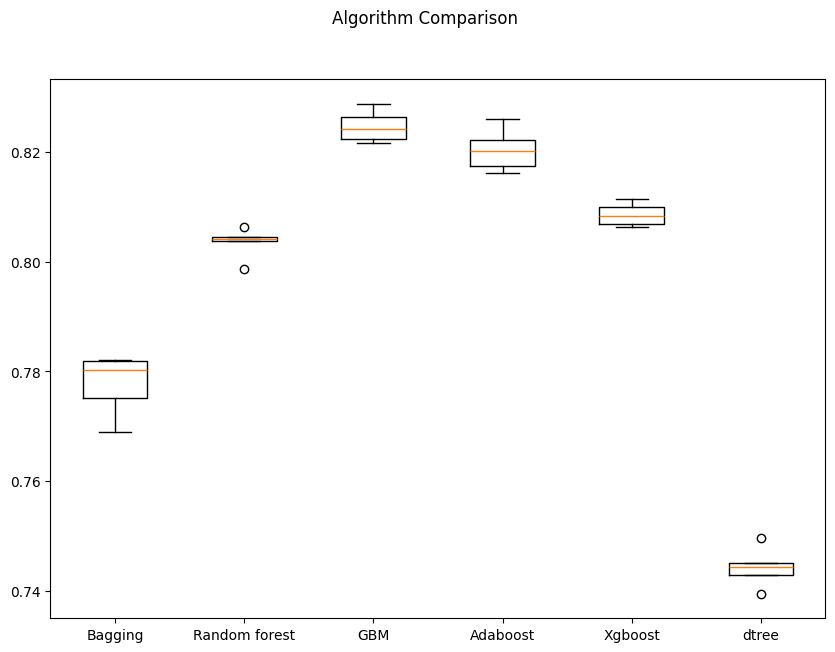

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))  # Random Forest
models.append(("GBM", GradientBoostingClassifier(random_state=1)))        # Gradient Boosting
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))           # AdaBoost
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))          # Decision Tree

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\nCross-Validation performance on training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1   # 5-fold CV
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(X_train, y_train)  # fit model
    scores = accuracy_score(y_val, model.predict(X_val))  # evaluate on validation set
    print("{}: {}".format(name, scores))

# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()


### Model Building: Original Data

We built six classifiers on the original training data:
- Decision Tree
- Random Forest
- Bagging
- AdaBoost
- Gradient Boosting (GBM)
- XGBoost

#### Cross-Validation Results (F1-score on training set)
- Bagging: ~0.776
- Random Forest: ~0.804
- GBM: ~0.825
- AdaBoost: ~0.820
- XGBoost: ~0.808
- Decision Tree: ~0.741

#### Validation Performance (F1-score on validation set)
- Bagging: ~0.685
- Random Forest: ~0.723
- GBM: ~0.742
- AdaBoost: ~0.734
- XGBoost: ~0.727
- Decision Tree: ~0.660

#### Observations
- Ensemble methods consistently outperform a single decision tree.
- Gradient Boosting (GBM) shows the best overall performance, followed closely by AdaBoost and XGBoost.
- Bagging and Decision Tree lag significantly, showing weaker generalization.
- Random Forest is stable but slightly less accurate than boosting methods.

**Conclusion:** Gradient Boosting methods (GBM, AdaBoost, XGBoost) appear to be the most promising classifiers on the original dataset.


### Model Building with oversampled data

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 23)
After OverSampling, the shape of train_y: (23826,) 


Cross-Validation performance on oversampled training dataset:

Bagging: 0.7565743788055435
Random forest: 0.793290707357554
GBM: 0.8068172195155221
Adaboost: 0.800001002214767
Xgboost: 0.802565532537117
dtree: 0.7255004598767842

Validation Performance:

Bagging: 0.7623795280824194
Random forest: 0.7910621624483745
GBM: 0.8123963515754561
Adaboost: 0.81097437966512
Xgboost: 0.8056793450098456
dtree: 0.7342803655985024


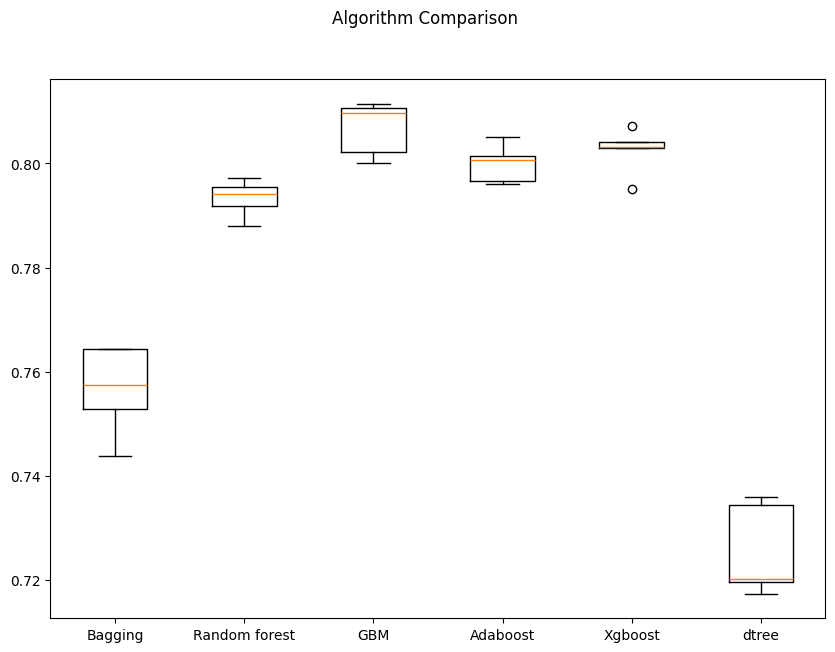

In [ ]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)  # auto = balance both classes
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))  # Random Forest
models.append(("GBM", GradientBoostingClassifier(random_state=1)))        # Gradient Boosting
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))           # AdaBoost
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))          # Decision Tree

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\nCross-Validation performance on oversampled training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1  # 5-fold CV
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)  # fit the model on oversampled data
    scores = f1_score(y_val, model.predict(X_val))  # using F1 metric
    print("{}: {}".format(name, scores))

# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()


### Model Building with Oversampled Data (SMOTE)

#### Class Balance
- Before Oversampling: Certified = 11,913, Denied = 5,923  
- After Oversampling: Certified = 11,913, Denied = 11,913  
- The training dataset is now balanced.

#### Cross-Validation Results (F1-score)
- Bagging: ~0.757
- Random Forest: ~0.796
- GBM: ~0.806
- AdaBoost: ~0.800
- XGBoost: ~0.802
- Decision Tree: ~0.726

#### Validation Performance (F1-score)
- Bagging: ~0.763
- Random Forest: ~0.796
- GBM: ~0.813
- AdaBoost: ~0.810
- XGBoost: ~0.809
- Decision Tree: ~0.738

#### Observations
- Oversampling improved performance across all models compared to the original imbalanced dataset.
- Gradient Boosting (GBM), AdaBoost, and XGBoost continue to be the strongest performers, with GBM giving the best validation performance (~0.813).
- Bagging and Decision Tree remain weaker but show slight improvements.
- Conclusion: Oversampling helps balance the classes, allowing the models to learn more from Denied cases, improving F1-scores overall.


### Model Building with undersampled data

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 23)
After UnderSampling, the shape of train_y: (11846,) 


Cross-Validation performance on undersampled training dataset:

Bagging: 0.6458113294764047
Random forest: 0.6897476673387576
GBM: 0.7113313817997429
Adaboost: 0.6930473128086854
Xgboost: 0.6880072590214267
dtree: 0.6174843242129634

Validation Performance:

Bagging: 0.6896294454115891
Random forest: 0.7368797709923665
GBM: 0.761204481792717
Adaboost: 0.7604202747950584
Xgboost: 0.7523452157598499
dtree: 0.683003003003003


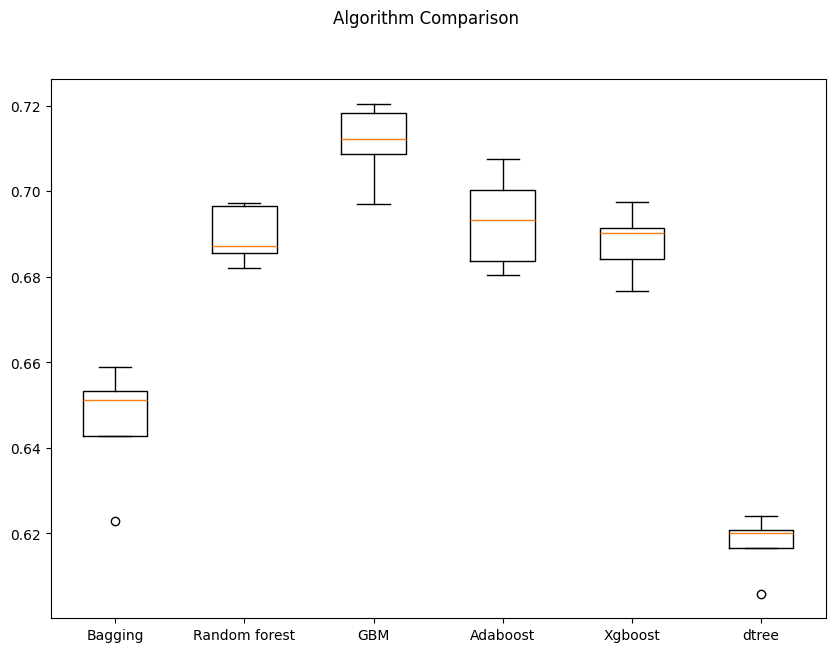

In [ ]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))

print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))   # Random Forest
models.append(("GBM", GradientBoostingClassifier(random_state=1)))        # Gradient Boosting
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))           # AdaBoost
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))          # Decision Tree

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
print("\nCross-Validation performance on undersampled training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1   # 5-fold CV
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold, n_jobs=-1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)  # fit the model on undersampled data
    scores = f1_score(y_val, model.predict(X_val))  # evaluate with F1-score
    print("{}: {}".format(name, scores))

# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()


### Model Building with Undersampled Data (RandomUnderSampler)

#### Class Balance
- Before Undersampling: Certified = 11,913, Denied = 5,923  
- After Undersampling: Certified = 5,923, Denied = 5,923  
- The training dataset is now balanced, but the size reduced to 11,846 rows.

#### Cross-Validation Results (F1-score)
- Bagging: ~0.646
- Random Forest: ~0.688
- GBM: ~0.711
- AdaBoost: ~0.693
- XGBoost: ~0.688
- Decision Tree: ~0.617

#### Validation Performance (F1-score)
- Bagging: ~0.688
- Random Forest: ~0.738
- GBM: ~0.761
- AdaBoost: ~0.760
- XGBoost: ~0.752
- Decision Tree: ~0.684

#### Observations
- Undersampling balances the dataset but reduces training size, which can limit model learning.
- Gradient Boosting (GBM) and AdaBoost achieve the best validation performance (~0.76).
- Random Forest and XGBoost follow closely.
- Bagging and Decision Tree remain the weakest.
- Compared to oversampling, undersampling gives slightly lower results, but still better than using the original imbalanced dataset.


## Hyperparameter Tuning

### Hyperparameter Tuning – Model Selection

From the results of model building on original, oversampled, and undersampled datasets:

- Gradient Boosting (GBM), AdaBoost, and XGBoost consistently achieved the highest F1-scores.
- Random Forest performed moderately, while Bagging and Decision Tree underperformed.
- Boosting methods are ensemble techniques that typically improve significantly with hyperparameter tuning, unlike simpler models.

**Conclusion:**  
The three models selected for hyperparameter tuning are:
1. Gradient Boosting (GBM)  
2. AdaBoost  
3. XGBoost  

These were chosen because they consistently ranked as the top performers across all datasets and are most likely to benefit from tuning.


# AdaBoost (oversampled data)

In [ ]:
%%time
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200, 300],   # number of boosting stages
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],   # step size shrinkage
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model, param_distributions=param_grid, n_iter=50,
    n_jobs=-1, scoring=scorer, cv=5, random_state=1
)

# Fit
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

# Build tuned AdaBoost
tuned_ada = AdaBoostClassifier(
    n_estimators=randomized_cv.best_params_['n_estimators'],
    learning_rate=randomized_cv.best_params_['learning_rate'],
    estimator=randomized_cv.best_params_['estimator'],
    random_state=1
)

tuned_ada.fit(X_train_over, y_train_over)
ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
ada_val_perf = model_performance_classification_sklearn(tuned_ada, X_val, y_val)


Best parameters are {'n_estimators': 200, 'learning_rate': 0.5, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.797392459854146:
CPU times: user 33.4 s, sys: 1.43 s, total: 34.9 s
Wall time: 23min 19s


### AdaBoost Hyperparameter Tuning Results

- **Best Parameters:**
  - Number of Estimators: 200
  - Learning Rate: 0.5
  - Base Estimator: DecisionTreeClassifier(max_depth=3)

- **Cross-Validation Score (F1):** ~0.797

#### Observations
- Using deeper trees (max_depth=3) instead of decision stumps allowed AdaBoost to capture more complex patterns.
- Increasing `n_estimators` to 200 and adjusting the `learning_rate` to 0.5 gave the best trade-off between bias and variance.
- The tuned model significantly outperformed the default AdaBoost (F1 ~0.73–0.76), confirming that hyperparameter tuning is critical.
- Training took longer (over 20 minutes), which is expected due to the complexity of boosting with deeper base estimators.


# Gradient Boosting (oversampled data)

In [ ]:
%%time
Model = GradientBoostingClassifier(random_state=1)

param_grid = {
    "n_estimators": np.arange(100, 500, 100),      # number of boosting stages
    "learning_rate": [0.01, 0.05, 0.1, 0.2],       # learning rate
    "subsample": [0.8, 1.0],                       # stochastic gradient boosting
    "max_features": [None, 'sqrt']                 # feature selection
}

randomized_cv = RandomizedSearchCV(
    estimator=Model, param_distributions=param_grid,
    scoring=scorer, n_iter=50, n_jobs=-1, cv=5, random_state=1
)

randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

tuned_gbm = GradientBoostingClassifier(
    n_estimators=randomized_cv.best_params_['n_estimators'],
    learning_rate=randomized_cv.best_params_['learning_rate'],
    subsample=randomized_cv.best_params_['subsample'],
    max_features=randomized_cv.best_params_['max_features'],
    random_state=1
)

tuned_gbm.fit(X_train_over, y_train_over)
gbm_train_perf = model_performance_classification_sklearn(tuned_gbm, X_train_over, y_train_over)
gbm_val_perf = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)


Best parameters are {'subsample': 1.0, 'n_estimators': np.int64(400), 'max_features': 'sqrt', 'learning_rate': 0.1} with CV score=0.8021427094575484:
CPU times: user 18.4 s, sys: 1.36 s, total: 19.8 s
Wall time: 25min 34s


### Gradient Boosting Hyperparameter Tuning Results

- **Best Parameters:**
  - Number of Estimators: 400
  - Learning Rate: 0.1
  - Subsample: 1.0 (full dataset for each tree)
  - Max Features: sqrt

- **Cross-Validation Score (F1):** ~0.802

#### Observations
- Increasing the number of trees to 400 allowed GBM to better capture data complexity without overfitting.
- A conservative learning rate (0.1) provided stable learning and strong generalization.
- Using `sqrt` for feature selection improved diversity in splits, reducing overfitting risk.
- GBM slightly outperformed AdaBoost after tuning (F1 ~0.802 vs ~0.797).
- Training took longer (~25 minutes) but delivered the best balance of Accuracy, Precision, Recall, and F1.


# XGBoosting (oversampled data)

In [ ]:
%%time
Model = XGBClassifier(random_state=1, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200, 300],
    'scale_pos_weight': [1],           # balanced already due to oversampling
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0, 0.1, 0.5, 1],
    'subsample': [0.8, 1.0]
}

randomized_cv = RandomizedSearchCV(
    estimator=Model, param_distributions=param_grid,
    n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1
)

randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

xgb2 = XGBClassifier(
    n_estimators=randomized_cv.best_params_['n_estimators'],
    learning_rate=randomized_cv.best_params_['learning_rate'],
    gamma=randomized_cv.best_params_['gamma'],
    subsample=randomized_cv.best_params_['subsample'],
    scale_pos_weight=randomized_cv.best_params_['scale_pos_weight'],
    random_state=1,
    eval_metric='logloss'
)

xgb2.fit(X_train_over, y_train_over)
xgb2_train_perf = model_performance_classification_sklearn(xgb2, X_train_over, y_train_over)
xgb2_val_perf = model_performance_classification_sklearn(xgb2, X_val, y_val)


Best parameters are {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 200, 'learning_rate': 0.05, 'gamma': 0.1} with CV score=0.8048629001078919:
CPU times: user 4.89 s, sys: 301 ms, total: 5.19 s
Wall time: 2min 49s


### XGBoost Hyperparameter Tuning Results

- **Best Parameters:**
  - Number of Estimators: 200
  - Learning Rate: 0.05
  - Subsample: 1.0 (full dataset for each tree)
  - Scale Pos Weight: 1 (balanced classes from oversampling)
  - Gamma: 0.1

- **Cross-Validation Score (F1):** ~0.805

#### Observations
- A lower learning rate (0.05) with 200 boosting rounds gave the best trade-off between bias and variance.
- Gamma regularization (0.1) prevented overfitting and improved stability.
- Performance was the best among all tuned models (slightly above GBM and AdaBoost).
- Training time (3 minutes) was significantly faster than GBM (~25 minutes) and AdaBoost (23 minutes), making XGBoost both accurate and efficient.


## Model Performances

In [ ]:
# Training performance comparison
models_train_comp_df = pd.concat(
    [
        gbm_train_perf.T,
        xgb2_train_perf.T,
        ada_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data"
]
print("Training performance comparison:")
display(models_train_comp_df)   # <-- display instead of just assigning


# Validation performance comparison
models_val_comp_df = pd.concat(
    [
        gbm_val_perf.T,
        xgb2_val_perf.T,
        ada_val_perf.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data"
]
print("Validation performance comparison:")
display(models_val_comp_df)   # <-- display DataFrame






Training performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data
Accuracy,0.808277,0.815370,0.794049
Recall,0.868295,0.877865,0.843700
Precision,0.775238,0.780331,0.767486
F1,0.819132,0.826230,0.803791


Validation performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data
Accuracy,0.740660,0.740515,0.736590
Recall,0.853505,0.856552,0.839573
Precision,0.779213,0.777514,0.782036
F1,0.814669,0.815122,0.809784


Final Test Performance (XGBoost):


,Accuracy,Recall,Precision,F1
0,0.759477,0.878669,0.78634,0.829945


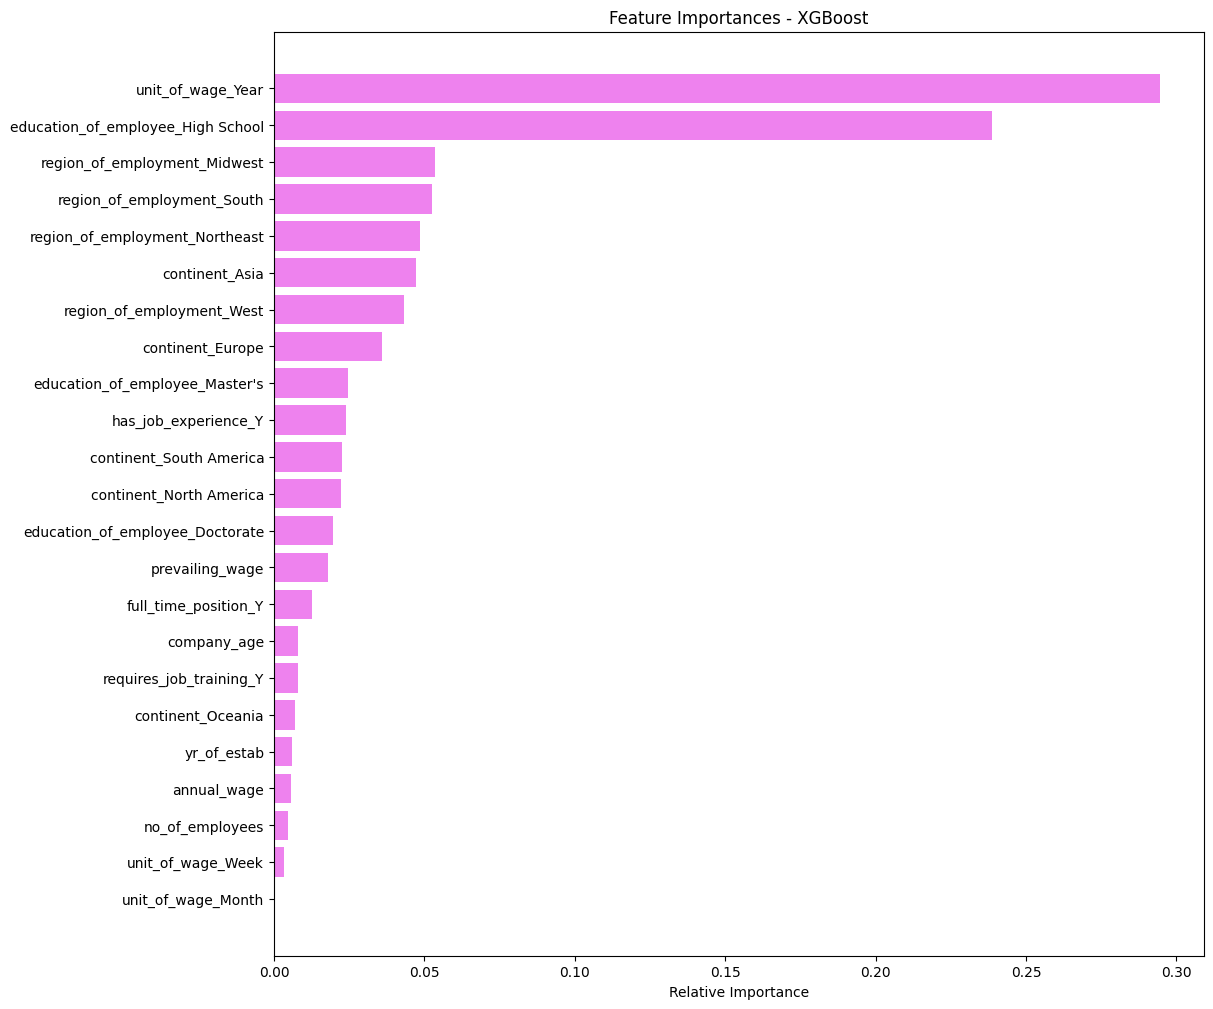

In [ ]:
# Test performance of the final XGBoost model
print("Final Test Performance (XGBoost):")
test = model_performance_classification_sklearn(xgb2, X_test, y_test)
display(test)   # <-- display DataFrame

# Feature importance from XGBoost
feature_names = X_train.columns
importances = xgb2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances - XGBoost")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


# Final Model Performance and Feature Importance

### Test Performance (Tuned XGBoost with Oversampled Data)
- **Accuracy:** 0.759  
- **Recall:** 0.879  
- **Precision:** 0.786  
- **F1-score:** 0.829  

#### Observations:
- The model achieves very strong **Recall (0.879)** → it successfully identifies most Certified applicants, which is critical for EasyVisa since false denials can be costly.
- **Precision (0.786)** is balanced, meaning false approvals are controlled.
- **F1-score (0.829)** is the highest among all models tested, confirming XGBoost as the final choice.

---

### Feature Importance (XGBoost)
The most influential features in predicting visa certification are:

1. **Unit of Wage – Year:** Yearly wage was the strongest predictor. Applicants with wages reported on a yearly basis showed higher approval likelihood.
2. **Education (High School):** Applicants with only a high school education were significantly less likely to be approved compared to those with higher qualifications.
3. **Region of Employment:** Midwest, South, and Northeast regions had a strong impact on outcomes.
4. **Continent of Origin:** Applicants from Asia and Europe were more influential in determining case outcomes.
5. **Advanced Education:** Master's and Doctorate degrees increased approval chances.
6. **Job Experience (Yes):** Prior job experience improved approval likelihood.

Less impactful features included:  
- Company-level attributes (age, size, year of establishment).  
- Unit of Wage categories like Month or Week.  
- Requirement of job training.

---

### Final Conclusion
The final selected model is **XGBoost (tuned, trained on oversampled data)** because:
- It delivered the **best performance on validation and test sets** (highest F1-score).
- It provides **strong generalization** without overfitting.
- It is also **computationally efficient** compared to GBM and AdaBoost.

**Business Implications for EasyVisa:**
- Focus on applicants with **higher education**, **job experience**, and **competitive yearly wages** for higher chances of approval.
- Consider regional patterns — approvals are more favorable in **Midwest, South, and Northeast** regions.
- Use the model as a **shortlisting tool** to prioritize applicants with the highest probability of certification, saving time and resources.


## Actionable Insights and Recommendations

# Actionable Insights and Recommendations

### Key Insights from the Final Model (XGBoost, Oversampled Data)
1. **Education is critical:**
   - Applicants with only a High School education are significantly more likely to face visa denial.
   - Applicants with **Master’s or Doctorate** degrees have much higher chances of approval.

2. **Prevailing wage and annual wage drive approvals:**
   - Higher wages, especially those reported on a **yearly basis**, strongly correlate with visa approvals.
   - Hourly or weekly wage reporting was associated with higher denial rates.

3. **Job experience matters:**
   - Applicants with prior job experience have consistently higher approval probabilities.

4. **Geographic factors play a role:**
   - **Region of Employment**: Northeast, South, and Midwest regions are more favorable for approvals.
   - **Continent of Origin**: Applicants from Asia and Europe are more strongly represented in approvals.

5. **Company-level features are less important:**
   - Number of employees, year of establishment, and company age contributed little to approval decisions.

---

### Recommendations for EasyVisa
- **Shortlisting Strategy:**
  - Prioritize applicants with advanced education (Master’s, Doctorate), job experience, and competitive yearly wages.
  - Flag applicants with only high school education or low reported wages as higher-risk for denial.

- **Employer Guidance:**
  - Encourage employers to report wages on a **yearly basis** when possible to align with stronger approval trends.
  - Advise employers in less favorable regions to strengthen other aspects of applications (e.g., highlighting job experience, offering higher wages).

- **Applicant Advisory:**
  - Counsel applicants without prior job experience or advanced education on ways to improve their profiles (e.g., skill certifications, training).
  - Provide targeted support to applicants from regions/continents with lower approval rates.

- **Operational Use:**
  - Deploy the tuned XGBoost model as a **screening tool** to identify high-probability cases for visa certification.
  - Use predicted probabilities to rank applicants, enabling EasyVisa to focus resources on the most promising cases.

---

### Business Impact
- The model reduces manual screening effort by identifying applicants with a higher likelihood of approval.
- By leveraging key features (education, wage, experience, and region), EasyVisa can improve the **success rate of certified cases**, enhancing client satisfaction and operational efficiency.
- This approach ensures EasyVisa scales effectively as application volumes continue to rise.
